In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/Users/vishalkumar/Documents/Arushi_Docs/Triple_ten/TripleTenGitHub/diabetes-prediction-app/data/diabetes.csv')

# First look at the data
print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset Overview:
Shape: (768, 9)

Column names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First few rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Basic statistics and data types
print("Data Types:")
print(df.dtypes)
print("\n" + "="*50)

print("Basic Statistics:")
display(df.describe())
print("\n" + "="*50)

print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)

print("Target Variable Distribution:")
print(df['Outcome'].value_counts())
print(f"Diabetes rate: {df['Outcome'].mean():.1%}")

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Basic Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Target Variable Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
Diabetes rate: 34.9%


In [4]:
# Check for impossible zero values
zero_cols = ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness', 'Insulin']

print("Zero values in each column:")
for col in zero_cols:
    zero_count = (df[col] == 0).sum()
    zero_percent = (zero_count / len(df)) * 100
    print(f"{col}: {zero_count} zeros ({zero_percent:.1f}%)")

print(f"\nRows with at least one impossible zero: {(df[zero_cols] == 0).any(axis=1).sum()}")

Zero values in each column:
Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
BMI: 11 zeros (1.4%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)

Rows with at least one impossible zero: 376


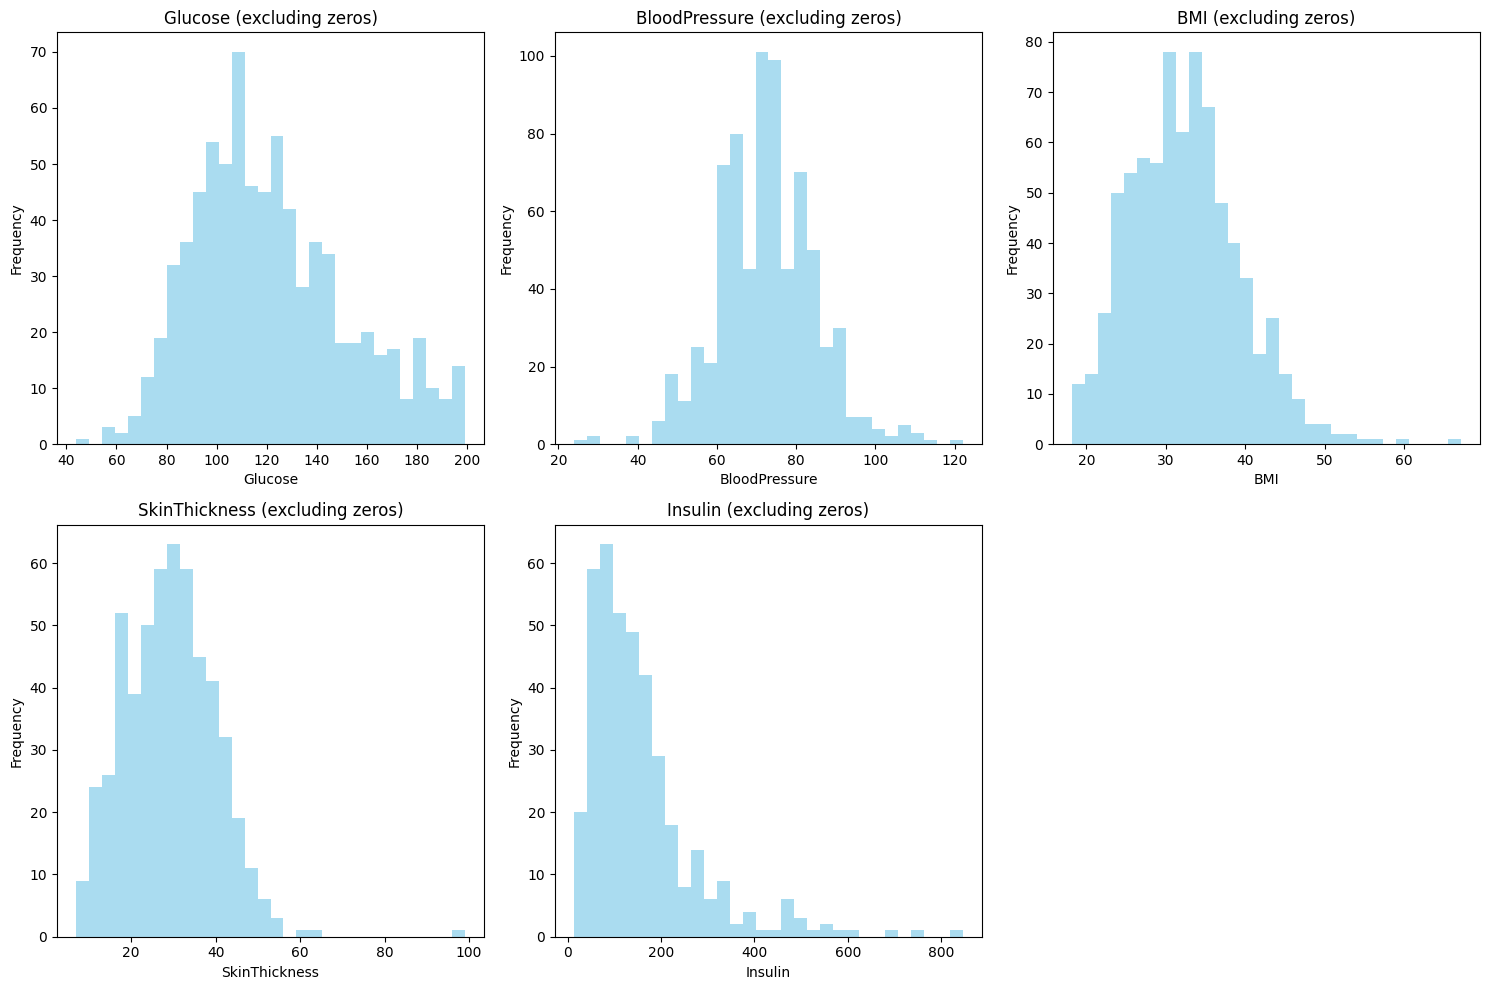

In [5]:
# Visualize the zero value problem
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

zero_cols = ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness', 'Insulin']

for i, col in enumerate(zero_cols):
    # Plot histogram excluding zeros
    non_zero_data = df[df[col] > 0][col]
    axes[i].hist(non_zero_data, bins=30, alpha=0.7, color='skyblue')
    axes[i].set_title(f'{col} (excluding zeros)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove empty subplot
axes[5].remove()

plt.tight_layout()
plt.show()

In [6]:
# Create boolean masks for missing values (zeros)
missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Creating a copy of the dataframe to keep the original data
df_copy=df.copy()

# Replacing the zeros with NaN
df_copy[missing_cols]=df_copy[missing_cols].replace(0,np.nan)

# Dropping the rows with missing values in Glucose or BMI
df_copy=df_copy.dropna(subset=['Glucose','BMI'])


## Further exploration (cleaned data)

Uses **`df_copy`**: sentinel zeros replaced with missing values on clinical fields; rows missing **Glucose** or **BMI** dropped.


Shape after cleaning: (752, 9)

Outcome counts:
 Outcome
0    488
1    264
Name: count, dtype: int64

Outcome proportion:
 Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


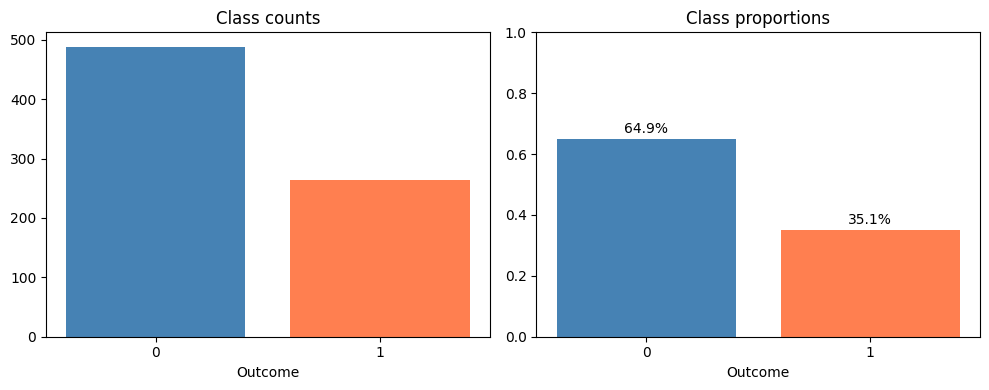

In [ ]:
# Target distribution (class balance)
eda_features = [c for c in df_copy.columns if c != "Outcome"]

print("Shape after cleaning:", df_copy.shape)
counts = df_copy["Outcome"].value_counts().sort_index()
props = df_copy["Outcome"].value_counts(normalize=True).sort_index()
print("\nOutcome counts:\n", counts)
print("\nOutcome proportion:\n", props.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(counts.index.astype(str), counts.values, color=["steelblue", "coral"])
axes[0].set_title("Class counts")
axes[0].set_xlabel("Outcome")

axes[1].bar(props.index.astype(str), props.values, color=["steelblue", "coral"])
axes[1].set_title("Class proportions")
axes[1].set_xlabel("Outcome")
axes[1].set_ylim(0, 1)
for i, v in enumerate(props.values):
    axes[1].text(float(i), v + 0.02, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()


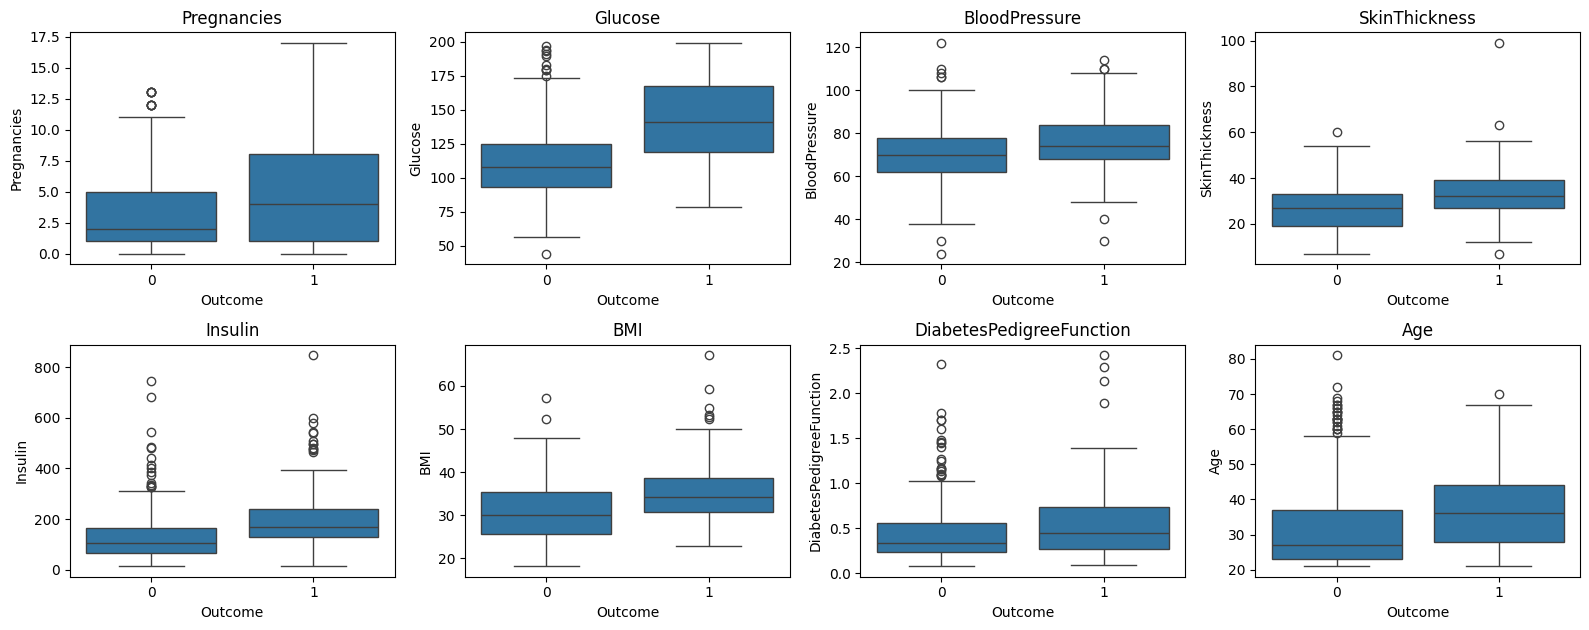

In [8]:
# Numeric features vs Outcome (boxplots)
n = len(eda_features)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()
for i, col in enumerate(eda_features):
    sns.boxplot(data=df_copy, x="Outcome", y=col, ax=axes[i])
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()


In [9]:
# Summary statistics by Outcome: mean | median | std
summary = (
    df_copy.groupby("Outcome")[eda_features]
    .agg(["mean", "median", "std"])
    .round(3)
)
summary


Pregnancies                Glucose                BloodPressure  \
               mean median    std     mean median     std          mean   
Outcome                                                                   
0             3.322    2.0  3.028  110.826  107.5  24.836        70.907   
1             4.830    4.0  3.750  142.489  140.5  29.644        75.249   

                       SkinThickness  ...  Insulin     BMI                \
        median     std          mean  ...      std    mean median    std   
Outcome                               ...                                  
0         70.0  12.175        27.278  ...  102.626  30.876  30.10  6.573   
1         74.0  12.292        32.961  ...  132.700  35.372  34.25  6.627   

        DiabetesPedigreeFunction                   Age                 
                            mean median    std    mean median     std  
Outcome                                                                
0                          0.430  0.338  0.295  31.309   27.0  11.608  
1                          0.553  0.452  0.374  37.015   36.0  10.990  

[2 rows x 24 columns]

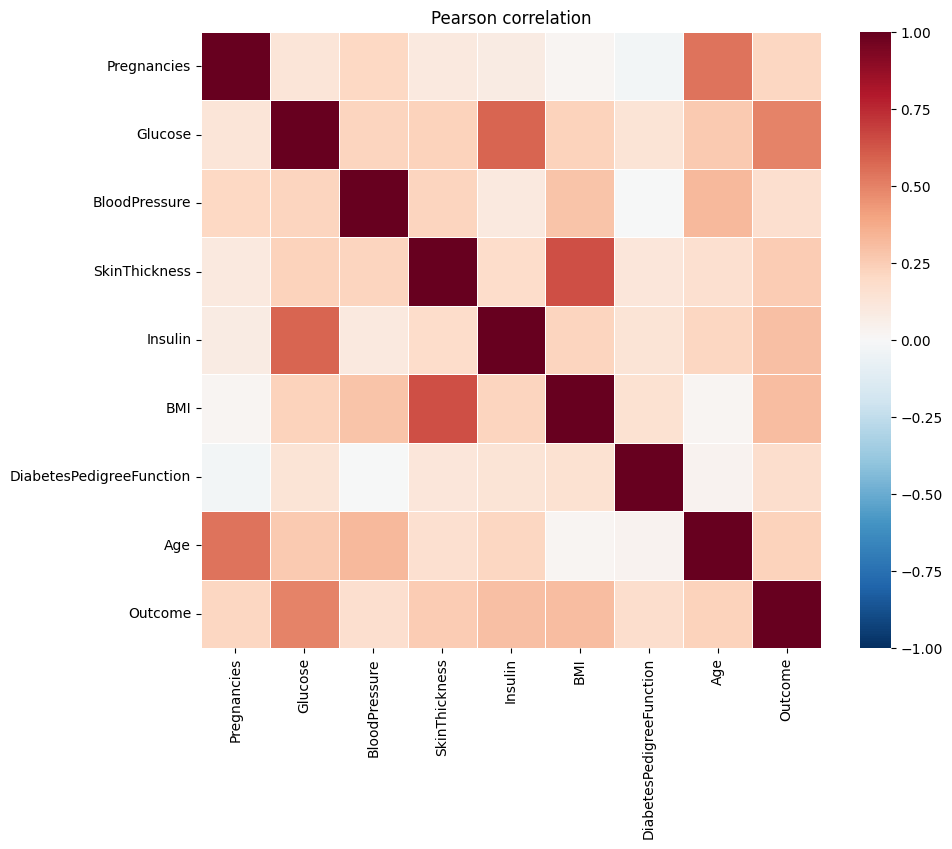

Features ranked by absolute correlation with Outcome:
Glucose                     0.494
BMI                         0.310
Insulin                     0.301
SkinThickness               0.255
Age                         0.233
Pregnancies                 0.213
DiabetesPedigreeFunction    0.178
BloodPressure               0.167
Name: Outcome, dtype: float64


In [10]:
# Correlation matrix (pairwise complete observations)
corr = df_copy.corr(numeric_only=True, min_periods=20)
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Pearson correlation")
plt.show()

ranked = corr["Outcome"].drop("Outcome").abs().sort_values(ascending=False)
print("Features ranked by absolute correlation with Outcome:")
print(ranked.round(3))
